In [ ]:
DATA_DIR = '../../data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE = DATA_DIR + 'sales_test.csv'

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Master
products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date']) #
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date']) #
geography = pd.read_csv(DATA_DIR + 'geography.csv')
# Transaction
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date']) #
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date']) #
returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date']) #
reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date']) #
# Analytical
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date']) #
# Operational
inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date']) #
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')

In [43]:
def quick_check(df, df_name):
    print(f"\n{'='*10} CHECKING TABLE: {df_name} {'='*10}")
    # Overall
    df.info()
    print(df.describe())

    # 1. Duplicates
    print(f"Duplicates: {df.duplicated().sum()} rows")

    # 2. Null values
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("Nulls found:\n", null_counts[null_counts > 0])
    else:
        print("No null values.")

    # 3. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

quick_check(products, 'products')
quick_check(customers, 'customers')
quick_check(promotions, 'promotions')
quick_check(geography, 'geography')
quick_check(orders, 'orders')
quick_check(order_items, 'order_items')
quick_check(payments, 'payments')
quick_check(shipments, 'shipments')
quick_check(returns, 'returns')
quick_check(reviews, 'reviews')
quick_check(sales, 'sales')
quick_check(inventory, 'inventory')
quick_check(web_traffic, 'web_traffic')


========== CHECKING TABLE: products ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB
        product_id         price          cogs
count  2412.000000   2412.000000   2412.000000
mean   1206.500000   4928.216231   3868.346732
std     696.428747   4776.737669   3878.584151
min       1.000000      9.056594      5.183829
25%     603.750000     59.444924     35.066367
50%    1206.500000   4399.605000   3184.934093
75%    1809.250000   77

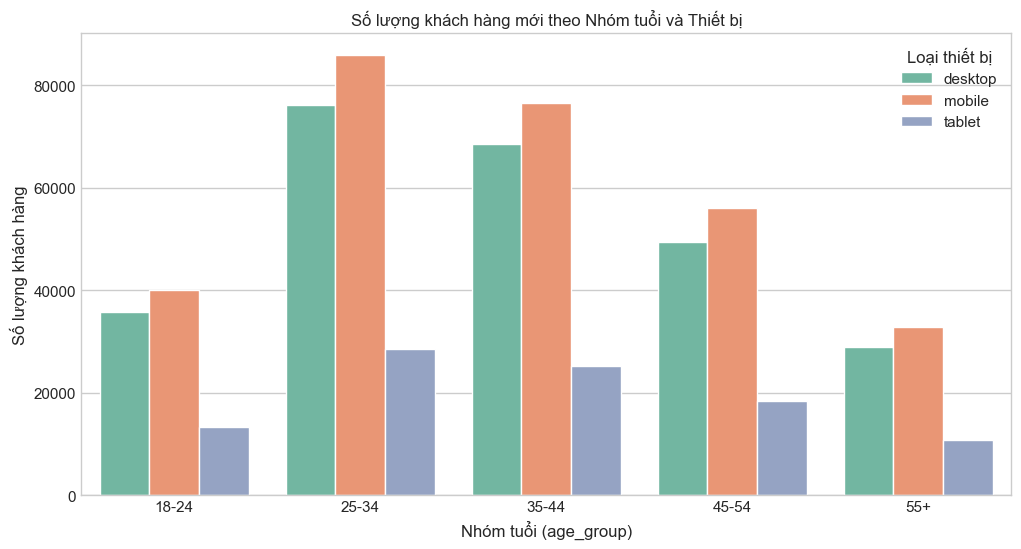

In [44]:
# Kết hợp dữ liệu Khách hàng và Đơn hàng
df_customer_orders = pd.merge(orders, customers, on='customer_id', how='left')

# Lọc các dòng có age_group không null để biểu đồ sạch hơn [cite: 166]
df_plot1 = df_customer_orders.dropna(subset=['age_group'])

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot1, x='age_group', hue='device_type', 
              order=sorted(df_plot1['age_group'].unique()))

plt.title('Số lượng khách hàng mới theo Nhóm tuổi và Thiết bị')
plt.xlabel('Nhóm tuổi (age_group)')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Loại thiết bị')
plt.show()


### 1. Phân tích tổng quan theo Nhóm tuổi
- Nhóm khách hàng chủ lực (25-44 tuổi): Đây là phân khúc đóng góp số lượng khách hàng mới cao nhất. Đặc biệt, nhóm 25-34 là nhóm dẫn đầu ở tất cả các loại thiết bị, cho thấy đây là đối tượng mục tiêu quan trọng nhất của doanh nghiệp.

- Nhóm trẻ (18-24) và Nhóm lớn tuổi (55+): Có số lượng khách hàng mới thấp hơn đáng kể so với các nhóm trung niên, cho thấy sản phẩm/dịch vụ có thể chưa thực sự thu hút hoặc chưa tiếp cận mạnh mẽ tới hai phân khúc đầu và cuối của tháp độ tuổi.

### 2. Phân tích theo Loại thiết bị (Device)
- Mobile (Điện thoại di động): Là thiết bị phổ biến nhất ở tất cả các nhóm tuổi. Đỉnh điểm là ở nhóm 25-34 với hơn 80.000 khách hàng mới. Điều này khẳng định chiến lược "Mobile-first" là bắt buộc.

- Desktop (Máy tính để bàn): Đứng vị trí thứ hai. Đáng chú ý, ở các nhóm tuổi từ 25 đến 54, khoảng cách giữa Desktop và Mobile không quá lớn so với nhóm trẻ (18-24). Điều này có thể gợi ý rằng khách hàng trung niên vẫn có thói quen sử dụng máy tính để thực hiện các giao dịch hoặc tìm kiếm dịch vụ.

- Tablet (Máy tính bảng): Luôn chiếm tỷ trọng thấp nhất ở mọi nhóm tuổi. Tuy nhiên, nhóm 25-34 và 35-44 vẫn có lượng sử dụng tablet cao hơn hẳn các nhóm còn lại.

### 3. Xu hướng phân bổ chi tiết theo từng nhóm tuổi
- Nhóm 18-24 tuổi: Đây là nhóm có sự chênh lệch rõ rệt nhất giữa các thiết bị. Lượng người dùng Mobile cao gấp khoảng 3 lần so với Tablet, cho thấy giới trẻ gần như chỉ tiếp cận dịch vụ qua điện thoại cá nhân.

- Nhóm 25-34 tuổi (Phân khúc trọng điểm): Đây là "đỉnh" của biểu đồ với số lượng khách hàng mới cao nhất ở tất cả các loại thiết bị. Đặc biệt, lượng người dùng Mobile vượt mốc 80.000, trong khi Desktop cũng đạt mức rất cao (hơn 75.000), chứng tỏ sự đa dạng trong cách tiếp cận của nhóm này.

- Nhóm 35-44 tuổi: Xu hướng tương tự như nhóm 25-34 nhưng với quy mô thấp hơn một chút. Tuy nhiên, lượng người dùng Tablet ở nhóm này vẫn duy trì ở mức khá tốt so với mặt bằng chung, cho thấy thói quen sử dụng thiết bị màn hình lớn vẫn tồn tại trong sinh hoạt hàng ngày.

- Nhóm 45-54 tuổi: Số lượng khách hàng bắt đầu giảm dần. Dù vậy, Mobile vẫn dẫn đầu với khoảng hơn 55.000 khách hàng mới, theo sau là Desktop với gần 50.000. Khoảng cách giữa hai thiết bị này khá hẹp, phản ánh thói quen làm việc trên máy tính vẫn rất phổ biến ở độ tuổi trung niên.

- Nhóm 55+ tuổi: Đây là phân khúc có số lượng khách hàng mới thấp nhất. Tỷ lệ sử dụng thiết bị giảm đều ở cả ba loại, với Mobile vẫn là kênh tiếp cận chính nhưng chỉ đạt mức hơn 30.000 khách hàng.

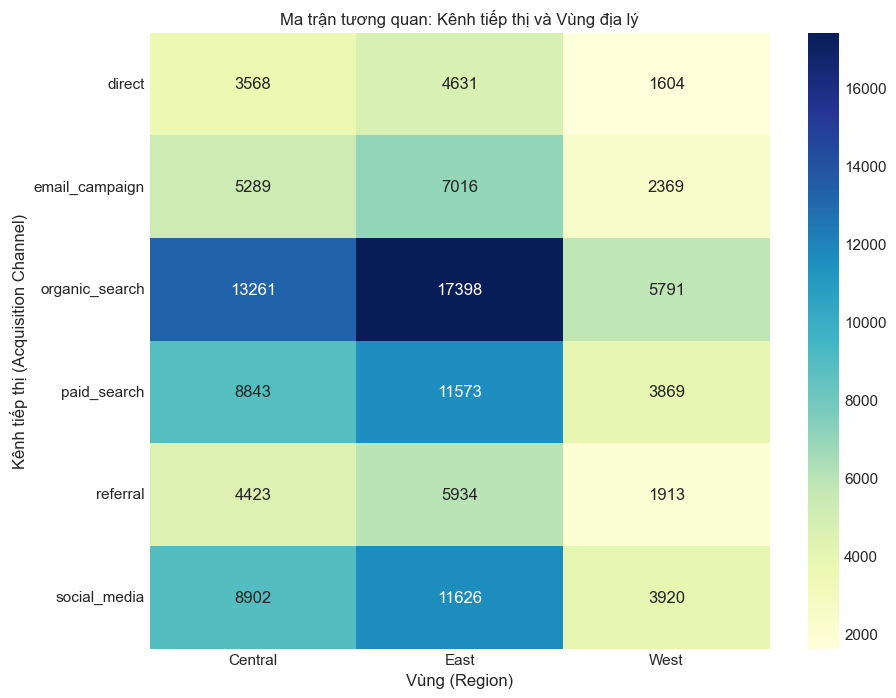

In [45]:
# Kết hợp Customers với Geography qua cột 'zip'
df_geo_customer = pd.merge(customers, geography, on='zip', how='left')

# Tạo bảng pivot tính số lượng khách hàng cho mỗi cặp (Kênh, Vùng)
heatmap_data = df_geo_customer.groupby(['acquisition_channel', 'region']).size().unstack(fill_value=0)

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Ma trận tương quan: Kênh tiếp thị và Vùng địa lý')
plt.xlabel('Vùng (Region)')
plt.ylabel('Kênh tiếp thị (Acquisition Channel)')
plt.show()

### 1. Phân tích Vùng địa lý (Region)
- Vùng East (Miền Đông): Đây là thị trường quan trọng nhất, chiếm ưu thế tuyệt đối ở tất cả các kênh tiếp thị. Mọi chỉ số tại đây đều cao hơn hẳn so với Central và West.

- Vùng Central (Miền Trung): Đứng vị trí thứ hai, đóng vai trò là thị trường tiềm năng duy trì sự ổn định.

- Vùng West (Miền Tây): Đây là vùng có hiệu suất thấp nhất. Các con số ở vùng này thường chỉ bằng khoảng 1/3 so với vùng East, cho thấy sự hiện diện của thương hiệu hoặc nhu cầu thị trường tại đây còn khá mỏng.

### 2. Phân tích Kênh tiếp thị (Acquisition Channel)
- Kênh dẫn đầu - Organic Search: Đây là "ngôi sao" của doanh nghiệp. Việc khách hàng tự tìm kiếm (tự nhiên) mang lại lượng truy cập/chuyển đổi lớn nhất, đặc biệt là tại vùng East (17.398). Điều này chứng tỏ hiệu quả SEO hoặc nhận diện thương hiệu tự nhiên đang làm rất tốt.

- Kênh quảng cáo trả phí - Paid Search & Social Media: Hai kênh này có hiệu suất tương đương nhau và giữ vai trò quan trọng thứ hai.

- Social Media nhỉnh hơn một chút so với Paid Search ở tất cả các vùng.

- Tại vùng East, Social Media đạt 11.626 trong khi Paid Search là 11.573.

- Các kênh bổ trợ - Email Campaign, Referral, Direct: Các kênh này đóng góp khiêm tốn hơn. Trong đó, Email Campaign tại vùng East (7.016) vẫn hiệu quả hơn hẳn so với việc khách hàng truy cập trực tiếp (Direct) hay qua giới thiệu (Referral).

### 3. Xu hướng phân bổ chi tiết
- Vùng East: Thể hiện sức mạnh áp đảo ở kênh Organic Search (17.398). Đây là nơi tập trung khách hàng chủ lực, phản ứng tốt với mọi chiến dịch marketing từ trả phí đến tự nhiên.

- Kênh Organic Search: Luôn đứng đầu bảng ở mọi vùng miền (Central: 13.261, West: 5.791). Điều này cho thấy khách hàng có xu hướng chủ động tìm kiếm sản phẩm/dịch vụ trên các công cụ tìm kiếm.

- Kênh Social Media: Hoạt động hiệu quả nhất ở vùng East và Central, cho thấy các nội dung trên mạng xã hội đang tiếp cận đúng đối tượng ở hai khu vực này.

- Kênh Direct & Referral: Có chỉ số thấp nhất, đặc biệt là tại vùng West (Direct: 1604, Referral: 1913). Điều này gợi ý rằng lòng trung thành thương hiệu hoặc mạng lưới giới thiệu tại miền Tây còn rất hạn chế.

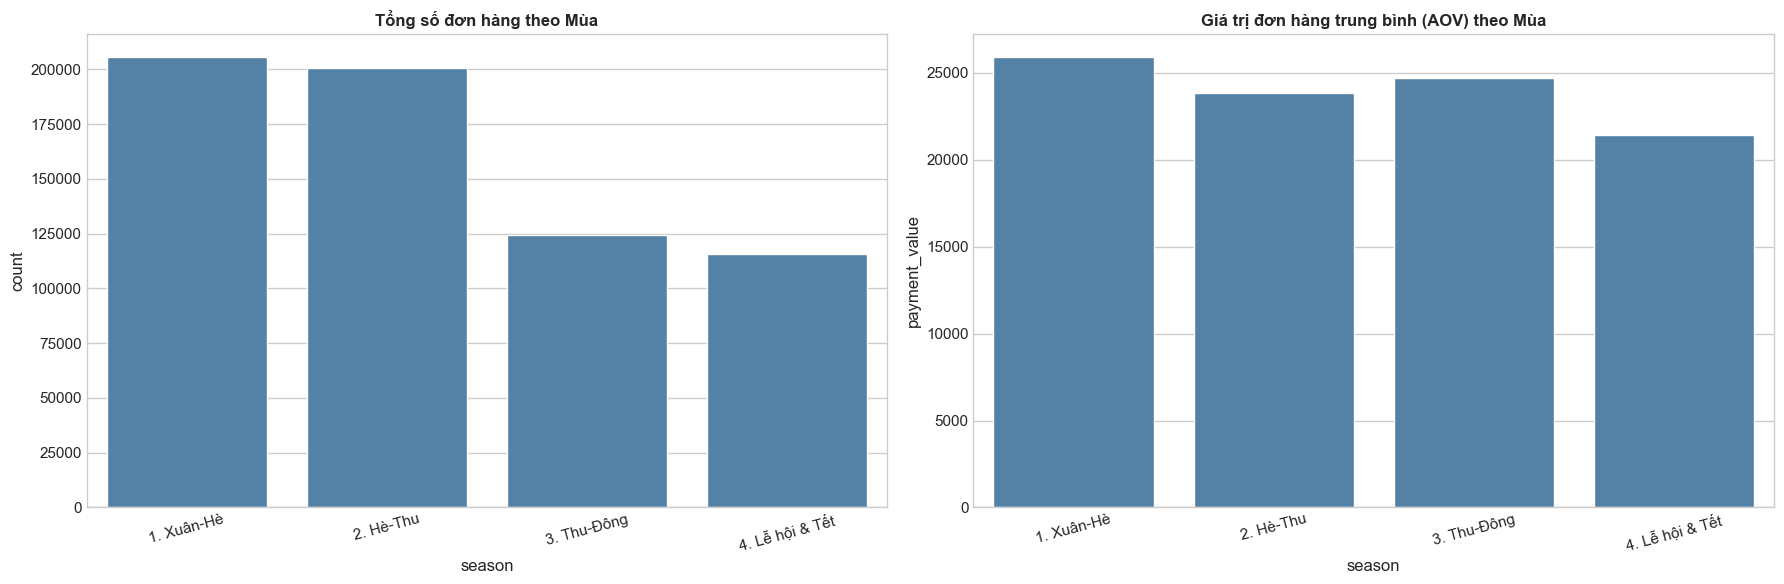

In [47]:
# 1. Định nghĩa hàm phân loại mùa
def get_season(month):
    if month in [3, 4, 5]:
        return '1. Xuân-Hè'
    elif month in [6, 7, 8]:
        return '2. Hè-Thu'
    elif month in [9, 10, 11]:
        return '3. Thu-Đông'
    else:
        return '4. Lễ hội & Tết'

# 2. Xử lý dữ liệu
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['season'] = orders['month'].apply(get_season)

# 3. Tính toán doanh thu và sửa lỗi NaN
order_val = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_with_val = orders.merge(order_val, on='order_id', how='left')

# --- BƯỚC SỬA LỖI QUAN TRỌNG ---
# Loại bỏ các đơn hàng không có dữ liệu thanh toán để tránh lỗi vẽ biểu đồ
orders_with_val = orders_with_val.dropna(subset=['payment_value'])

# 4. Trực quan hóa
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Số lượng đơn hàng theo Mùa
sns.countplot(data=orders_with_val, x='season', ax=ax[0], color='steelblue', 
              order=sorted(orders_with_val['season'].unique()))
ax[0].set_title('Tổng số đơn hàng theo Mùa', fontweight='bold')

# Biểu đồ 2: Giá trị đơn hàng trung bình (AOV) theo Mùa
sns.barplot(data=orders_with_val, x='season', y='payment_value', ax=ax[1], color='steelblue', 
            errorbar=None, order=sorted(orders_with_val['season'].unique()))
ax[1].set_title('Giá trị đơn hàng trung bình (AOV) theo Mùa', fontweight='bold')

# Tối ưu hiển thị
for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

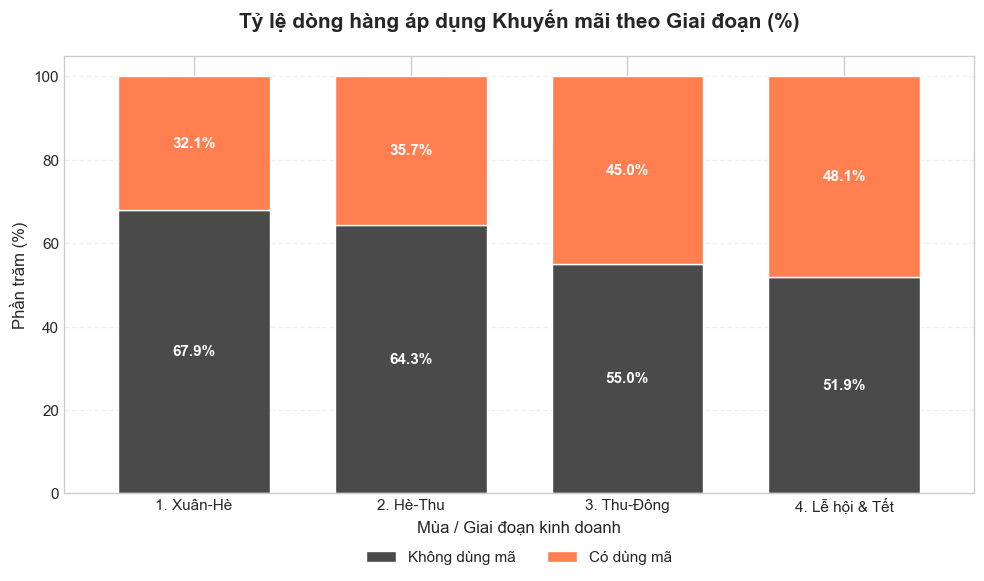

In [48]:
# 1. Hàm phân loại mùa
def get_season(month):
    if month in [3, 4, 5]: return '1. Xuân-Hè'
    elif month in [6, 7, 8]: return '2. Hè-Thu'
    elif month in [9, 10, 11]: return '3. Thu-Đông'
    else: return '4. Lễ hội & Tết'

# 2. Xử lý dữ liệu
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['season'] = orders['month'].apply(get_season)

# Kết hợp dữ liệu: order_items chứa promo_id [cite: 56], orders chứa thời gian [cite: 51]
df_merged = order_items.merge(orders[['order_id', 'season']], on='order_id', how='left')

# Kiểm tra áp dụng khuyến mãi (bao gồm cả promo_id_2 cho các khuyến mãi cộng dồn) [cite: 56, 40]
df_merged['has_promo'] = df_merged['promo_id'].notna() | df_merged['promo_id_2'].notna()

# 3. Tính toán tỷ lệ
promo_season = df_merged.groupby('season')['has_promo'].value_counts(normalize=True).unstack() * 100
promo_season = promo_season.reset_index()

# 4. Trực quan hóa với màu sắc mới
plt.figure(figsize=(10, 6))

# Sử dụng màu Cam san hô (Coral) cho "Có dùng mã" và Xám đậm cho "Không dùng mã" 
# để tạo sự tương phản mạnh, giúp người xem chú ý ngay vào hiệu quả khuyến mãi.
colors = ['#4A4A4A', '#FF7F50'] 

ax = promo_season.plot(kind='bar', x='season', stacked=True, 
                        color=colors, figsize=(10, 6), width=0.7)

# Định dạng biểu đồ [cite: 199, 200]
plt.title('Tỷ lệ dòng hàng áp dụng Khuyến mãi theo Giai đoạn (%)', fontweight='bold', fontsize=15, pad=20)
plt.ylabel('Phần trăm (%)', fontsize=12)
plt.xlabel('Mùa / Giai đoạn kinh doanh', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Không dùng mã', 'Có dùng mã'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# Thêm nhãn dữ liệu trực tiếp [cite: 204]
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

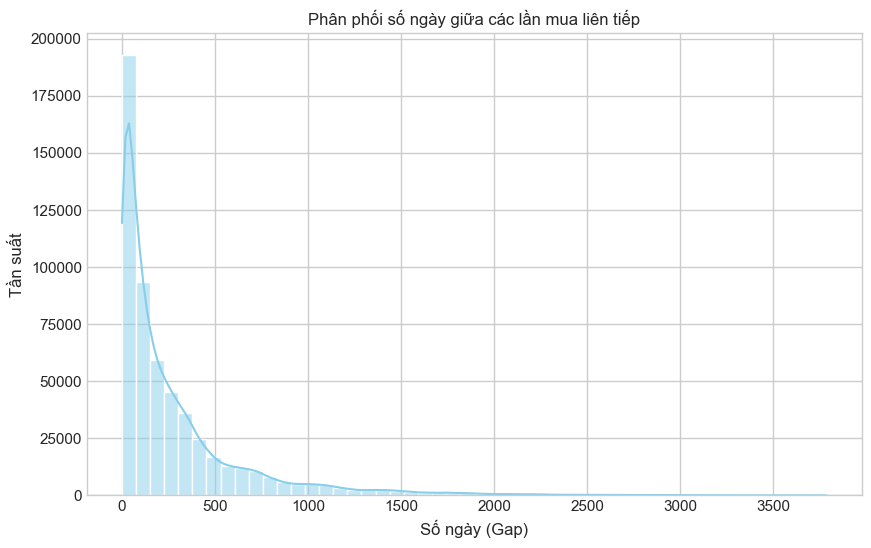

In [49]:
# --- Tiền xử lý dữ liệu Inter-order Gap ---
# Sắp xếp và tính khoảng cách ngày giữa các đơn của cùng 1 khách hàng
orders_sorted = orders.sort_values(['customer_id', 'order_date'])
orders_sorted['prev_order_date'] = orders_sorted.groupby('customer_id')['order_date'].shift(1)
orders_sorted['inter_order_gap'] = (orders_sorted['order_date'] - orders_sorted['prev_order_date']).dt.days

# --- 2.1 Histogram + KDE: Phân phối Inter-order Gap ---
plt.figure(figsize=(10, 6))
sns.histplot(orders_sorted['inter_order_gap'].dropna(), kde=True, color='skyblue', bins=50)
plt.title('Phân phối số ngày giữa các lần mua liên tiếp')
plt.xlabel('Số ngày (Gap)')
plt.ylabel('Tần suất')
plt.show()



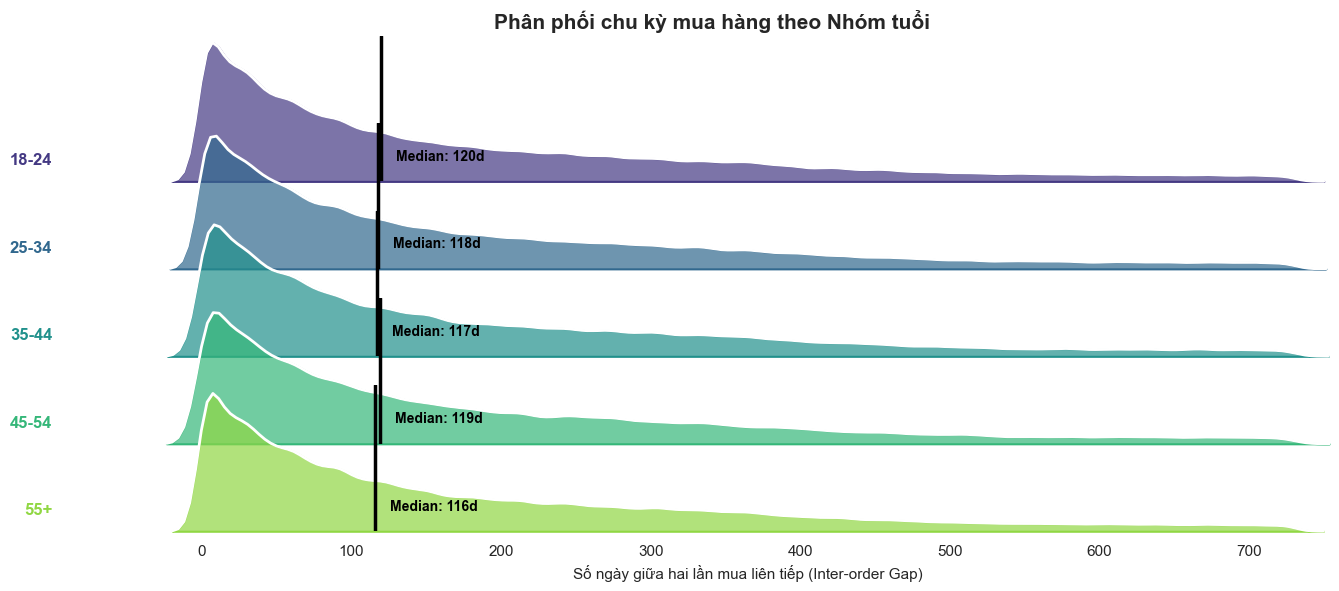

In [50]:
# 1. Lọc dữ liệu
orders_sorted = orders.sort_values(['customer_id', 'order_date'])
orders_sorted['order_date'] = pd.to_datetime(orders_sorted['order_date'])
orders_sorted['inter_order_gap'] = orders_sorted.groupby('customer_id')['order_date'].diff().dt.days

# Bước B: Lấy các khách hàng có nhiều hơn một đơn hàng [cite: 138]
df_ridge = orders_sorted.dropna(subset=['inter_order_gap'])

# Bước C: Kết hợp với thông tin nhóm tuổi (age_group) từ customers.csv 
df_ridge = df_ridge.merge(customers[['customer_id', 'age_group']], on='customer_id', how='left')

# Bước D: Loại bỏ giá trị age_group bị null để biểu đồ đẹp hơn [cite: 166]
df_ridge = df_ridge.dropna(subset=['age_group'])

df_filtered = df_ridge[df_ridge['inter_order_gap'] <= 730] 

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 2. Khởi tạo FacetGrid
# Lấy danh sách nhóm tuổi để đổ màu chính xác
age_groups = sorted(df_filtered['age_group'].unique())
palette = sns.color_palette("viridis", len(age_groups))

g = sns.FacetGrid(df_filtered, row="age_group", hue="age_group", 
                  aspect=10, height=1.2, palette="viridis")

# 3. Vẽ KDE
g.map(sns.kdeplot, "inter_order_gap", bw_adjust=.4, clip_on=False, 
      fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "inter_order_gap", clip_on=False, color="white", lw=2, bw_adjust=.4)

# 4. Tinh chỉnh hiển thị
g.fig.subplots_adjust(hspace=-0.4)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# 5. THÊM CHÚ THÍCH (ANNOTATION) VÀ MEDIAN
for i, (ax, name) in enumerate(zip(g.axes.flat, age_groups)):
    sub_df = df_filtered[df_filtered['age_group'] == name]
    median = sub_df['inter_order_gap'].median()
    
    # Vẽ đường Median đen đậm
    ax.axvline(median, color='black', linestyle='-', linewidth=2.5)
    
    # Text Median
    ax.text(median + 10, 0.001, f'Median: {int(median)}d', 
            color='black', fontsize=10, fontweight='bold')
    
    # THÊM CHÚ THÍCH TÊN NHÓM TUỔI: 
    # Ghi trực tiếp bên trái biểu đồ với màu tương ứng
    ax.text(-100, 0.001, name, fontweight="bold", color=palette[i],
            ha="right", va="center", transform=ax.transData, fontsize=12)

plt.suptitle("Phân phối chu kỳ mua hàng theo Nhóm tuổi", y=0.98, fontsize=15, fontweight='bold')
g.set_xlabels("Số ngày giữa hai lần mua liên tiếp (Inter-order Gap)", fontsize=11)
plt.xlim(0, 730)
plt.show()

### 1. Phân tích chỉ số Trung vị
#### Điểm đáng chú ý nhất là giá trị trung vị của các nhóm tuổi rất sát nhau, dao động trong khoảng từ 116 đến 120 ngày:

- Nhóm 18-24: 120 ngày (Chu kỳ dài nhất).
- Nhóm 45-54: 119 ngày.
- Nhóm 25-34: 118 ngày.
- Nhóm 35-44: 117 ngày.
- Nhóm 55+: 116 ngày (Chu kỳ ngắn nhất).

#### Nhận xét:
Độ tuổi không gây ra sự khác biệt lớn về thời gian quay lại mua hàng trung bình. Nhìn chung, khách hàng thường mất khoảng 4 tháng để phát sinh đơn hàng tiếp theo.

### 2. Hình dạng phân phối (Distribution Shape)
Tất cả các nhóm tuổi đều có dạng phân phối lệch phải (positive skew) rất rõ rệt:

- Đỉnh cao nhất (Mode): Nằm rất gần trục tung (khoảng 0 - 50 ngày). Điều này cho thấy một lượng lớn khách hàng có xu hướng mua lại rất nhanh ngay sau đơn hàng đầu tiên.

- Phần đuôi dài (Long tail): Kéo dài đến tận 700 ngày. Điều này phản ánh sự tồn tại của một nhóm khách hàng "vãng lai", khoảng cách giữa các lần mua cực kỳ xa nhau.

### 3. Xu hướng phân bổ chi tiết theo dòng
- Nhóm 18-24 tuổi: Có xu hướng thận trọng hơn với trung vị cao nhất (120 ngày). Đỉnh phân phối của nhóm này cũng nhọn và cao, cho thấy sự tập trung mua lại trong ngắn hạn là khá rõ nét nhưng khoảng cách trung bình vẫn bị kéo dài ra.
- Nhóm 25-34 và 35-44 tuổi: Hai nhóm này có hình dạng biểu đồ tương đối giống nhau. Đây là những nhóm khách hàng chủ lực có chu kỳ mua hàng ổn định và nhanh hơn một chút so với nhóm trẻ tuổi nhất.
- Nhóm 45-54 tuổi: Phân phối có phần trải rộng hơn ở giai đoạn sau trung vị, phản ánh thói quen mua hàng có độ trễ biến động hơn.
- Nhóm 55+ tuổi: Có chu kỳ mua hàng ngắn nhất (116 ngày). Tuy số lượng khách hàng mới của nhóm này ít (theo các biểu đồ trước), nhưng những người đã mua thì có xu hướng quay lại sớm hơn một chút so với các nhóm trẻ.

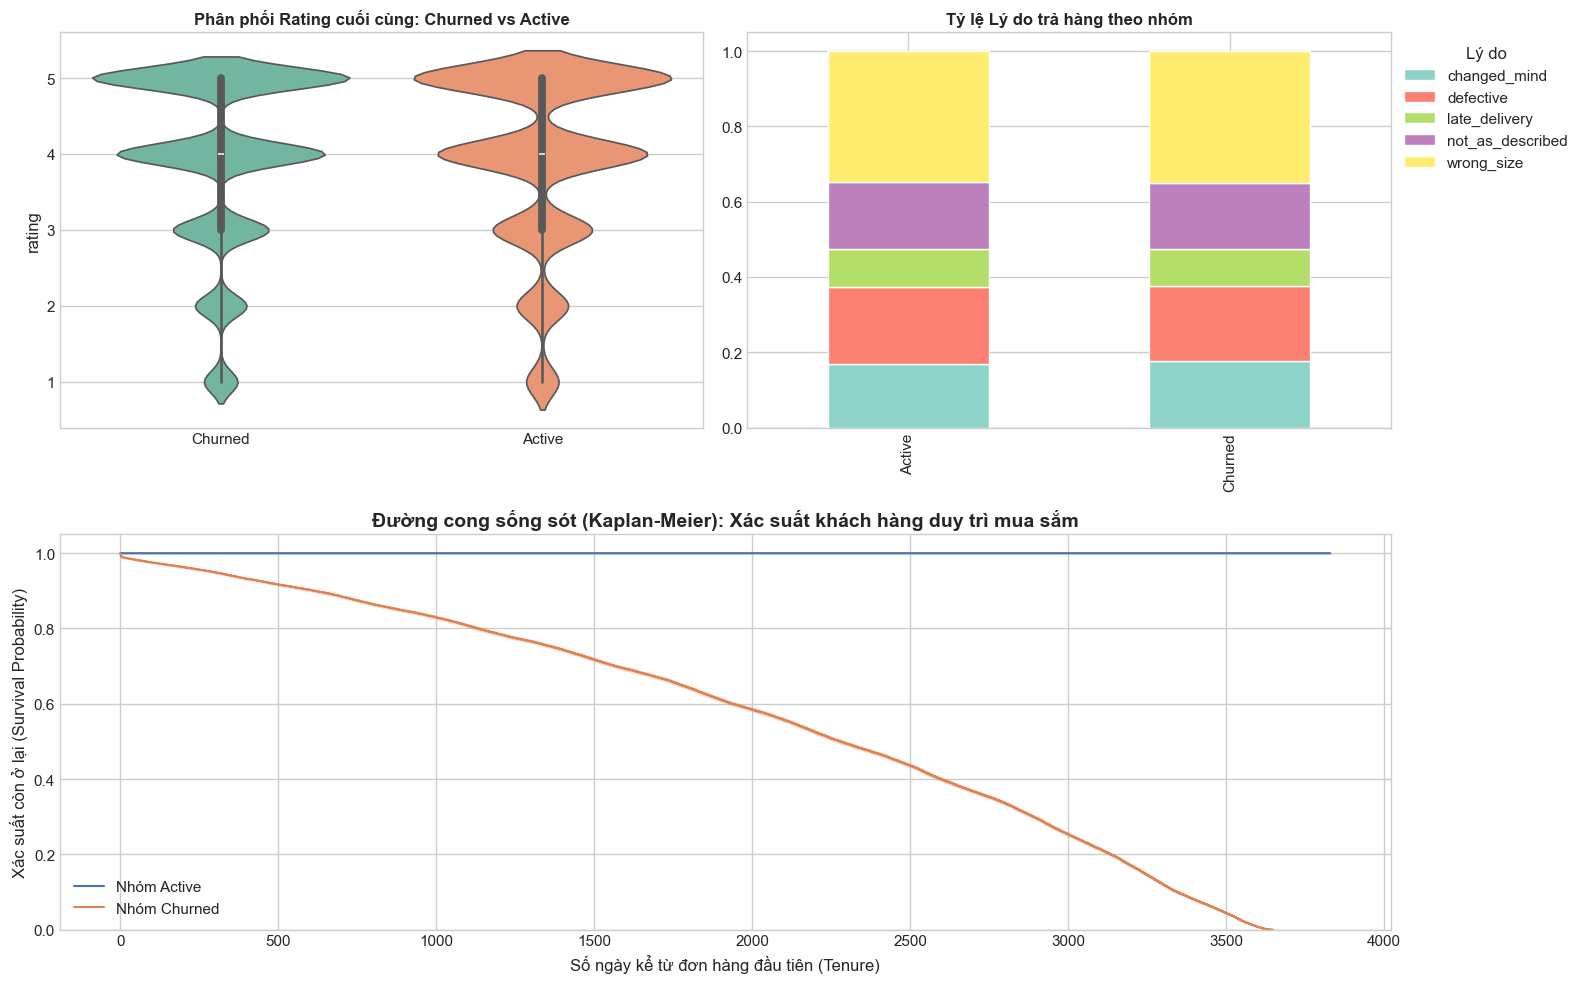

In [51]:
from lifelines import KaplanMeierFitter

# --- 1. CHUẨN BỊ DỮ LIỆU GỘP ---
obs_end = pd.to_datetime('2022-12-31')

# Tính toán Profile & Churn
cust_agg = orders.groupby('customer_id').agg(
    n_orders=('order_id', 'nunique'),
    first_date=('order_date', 'min'),
    last_date=('order_date', 'max')
).reset_index()

cust_agg['tenure'] = (cust_agg['last_date'] - cust_agg['first_date']).dt.days
cust_agg['is_churn'] = (cust_agg['n_orders'] >= 2) & ((obs_end - cust_agg['last_date']).dt.days > 180)
cust_agg['group'] = cust_agg['is_churn'].map({True: 'Churned', False: 'Active'})

# Lấy Rating cuối
last_ratings = reviews.sort_values('review_date').groupby('customer_id')['rating'].last()
df_master = cust_agg.merge(last_ratings, on='customer_id', how='left')

# --- 2. VẼ DASHBOARD (3 BIỂU ĐỒ) ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 10))

# Thiết lập layout: Biểu đồ Survival chiếm toàn bộ hàng dưới, 2 biểu đồ còn lại ở trên
ax1 = plt.subplot2grid((2, 2), (0, 0)) # Violin Plot
ax2 = plt.subplot2grid((2, 2), (0, 1)) # Stacked Bar
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2) # Survival Curve (Rộng nhất)

# Biểu đồ 1: Phân phối Rating cuối (Violin Plot)
sns.violinplot(data=df_master[df_master['n_orders'] >= 2], x='group', y='rating', 
               inner='box', palette='Set2', ax=ax1)
ax1.set_title('Phân phối Rating cuối cùng: Churned vs Active', fontweight='bold')
ax1.set_xlabel('')

# Biểu đồ 2: Lý do trả hàng (Stacked Bar)
ret_data = returns.merge(orders[['order_id', 'customer_id']], on='order_id') \
                  .merge(cust_agg[['customer_id', 'group']], on='customer_id')
pd.crosstab(ret_data['group'], ret_data['return_reason'], normalize='index') \
    .plot(kind='bar', stacked=True, colormap='Set3', ax=ax2)
ax2.set_title('Tỷ lệ Lý do trả hàng theo nhóm', fontweight='bold')
ax2.legend(title='Lý do', bbox_to_anchor=(1, 1))
ax2.set_xlabel('')

# Biểu đồ 3: Khả năng "sống sót" (Survival Curve)
kmf = KaplanMeierFitter()
for g_name, group in cust_agg[cust_agg['n_orders'] >= 2].groupby('group'):
    kmf.fit(group['tenure'], event_observed=group['is_churn'], label=f'Nhóm {g_name}')
    kmf.plot_survival_function(ax=ax3, ci_show=True) # ci_show để hiện khoảng tin cậy

ax3.set_title('Đường cong sống sót (Kaplan-Meier): Xác suất khách hàng duy trì mua sắm', fontweight='bold', fontsize=14)
ax3.set_xlabel('Số ngày kể từ đơn hàng đầu tiên (Tenure)')
ax3.set_ylabel('Xác suất còn ở lại (Survival Probability)')
ax3.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### 1. Phân phối Rating: Churned vs Active
- Biểu đồ so sánh điểm đánh giá cuối cùng giữa nhóm rời đi (Churned) và nhóm ở lại (Active).

- Đặc điểm chung: Cả hai nhóm đều có mật độ tập trung cao nhất ở mức 5 sao.

- Nhóm Churned có tỷ lệ đánh giá 1-2 sao cao hơn so với nhóm Active. Tuy nhiên, việc một lượng lớn khách hàng Churned vẫn đánh giá 5 sao cho thấy họ rời bỏ không phải vì chất lượng sản phẩm kém, mà có thể do dịch vụ khách hàng hoặc sự cạnh tranh từ đối thủ.

### 2. Tỷ lệ Lý do trả hàng theo nhóm
- Biểu đồ cột chồng bóc tách nguyên nhân khiến khách hàng hoàn trả sản phẩm.

- Các nguyên nhân chính: Cả hai nhóm Active và Churned đều có cơ cấu lý do trả hàng tương tự nhau.

- Wrong_size (Sai kích cỡ): Chiếm tỷ trọng lớn nhất (khoảng 35-40%).

- Defective (Hàng lỗi): Đứng thứ hai về mức độ phổ biến.

- Nhận xét: Sai sót về kích cỡ và lỗi sản phẩm là những vấn đề vận hành cốt lõi cần được xử lý để giảm tỷ lệ trả hàng chung cho toàn bộ hệ thống.

### 3. Đường cong sống sót (Kaplan-Meier)
- Đây là biểu đồ đo lường xác suất khách hàng còn duy trì mua sắm theo thời gian (Tenure - số ngày kể từ đơn đầu tiên).

- Nhóm Active (Đường xanh): Duy trì xác suất 1.0 vì đây là tập khách hàng vẫn đang hoạt động tại thời điểm thống kê.

- Nhóm Churned (Đường cam):

- Giai đoạn 0 - 1000 ngày: Xác suất sống sót giảm chậm, còn khoảng 80%.

- Giai đoạn 1000 - 2500 ngày: Tốc độ rơi rụng tăng nhanh, xác suất giảm xuống còn 50% ở mốc 2500 ngày.

- Giai đoạn sau 3000 ngày: Hầu hết khách hàng cũ đã rời bỏ hoàn toàn (xác suất tiến về 0).

### 4. Xu hướng phân bổ chi tiết
- Về Rating: Đa số khách hàng rời đi vẫn để lại phản hồi tốt (5 sao), điều này cảnh báo doanh nghiệp rằng sự hài lòng trên bề mặt (rating) không đồng nghĩa với việc khách hàng sẽ gắn bó lâu dài.

- Về Trả hàng: Lỗi vận hành (sai size) là rào cản lớn nhất. Dù khách hàng có trung thành đến đâu, việc gặp lỗi này thường xuyên cũng sẽ gây ức chế.

- Về Tuổi thọ khách hàng: Mốc 2500 ngày là điểm gãy quan trọng, nơi một nửa tập khách hàng cũ sẽ biến mất. Tốc độ rời bỏ tăng dần theo thời gian chứ không diễn ra đột ngột ở giai đoạn đầu.

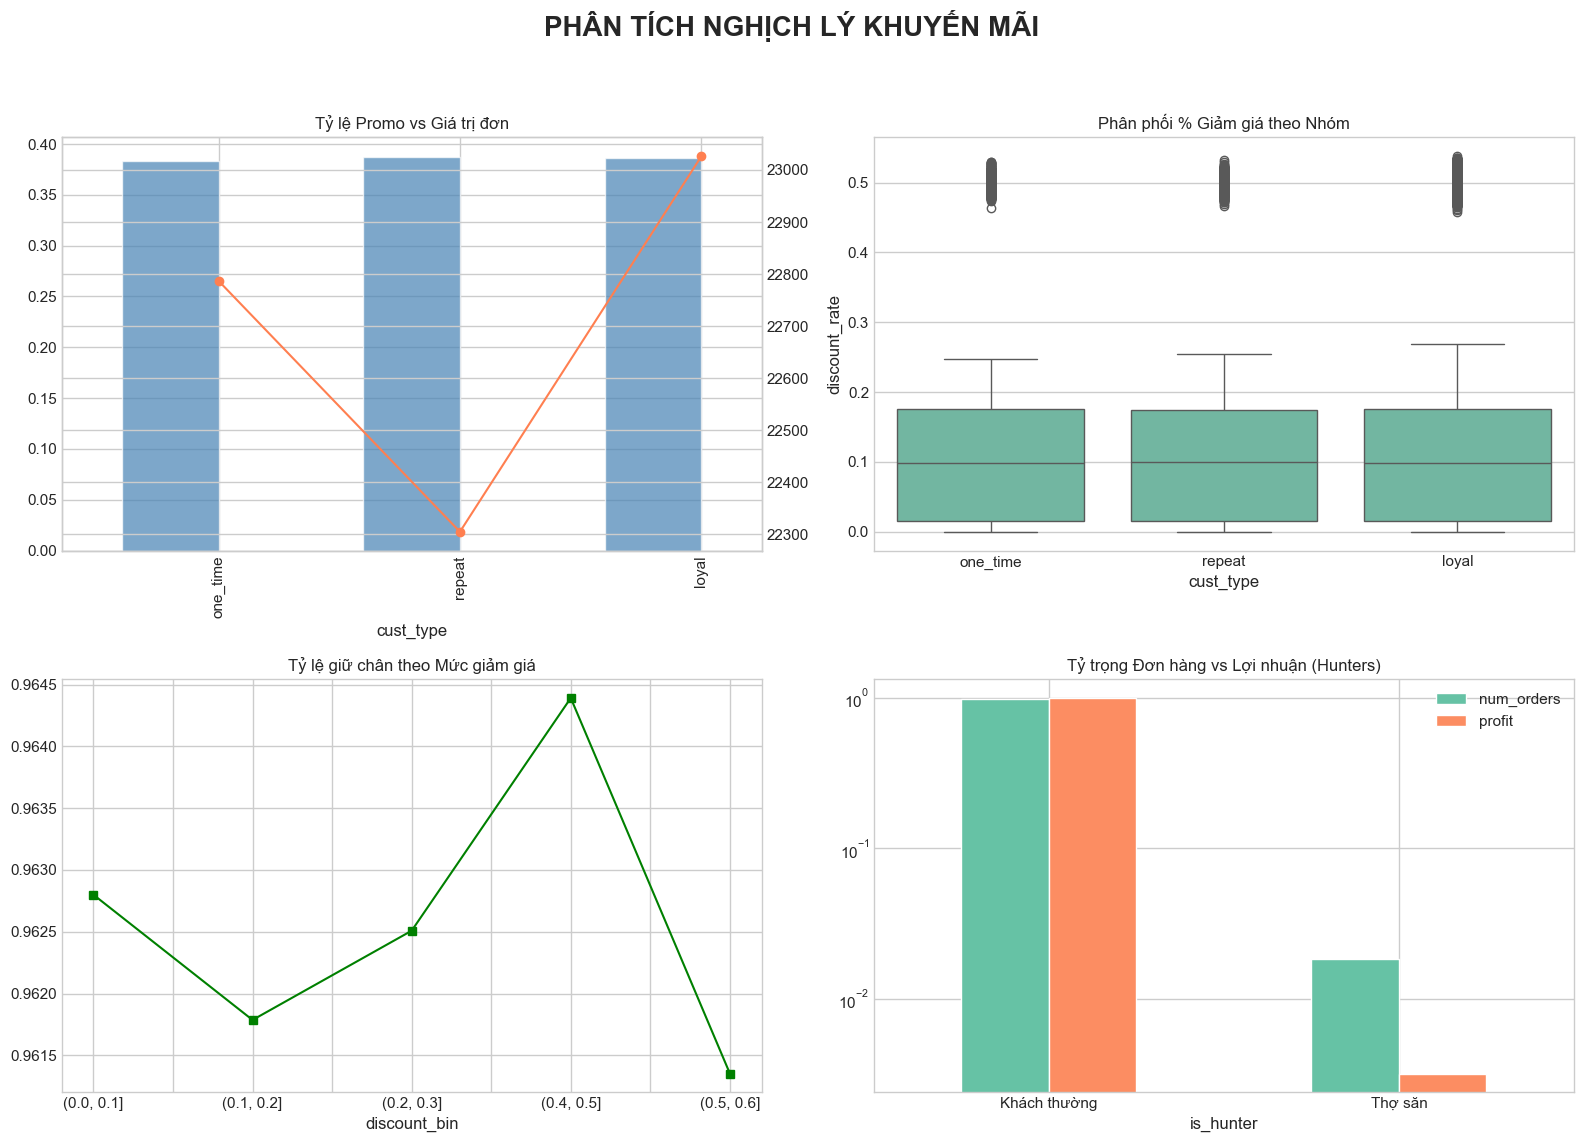

In [ ]:
import numpy as np  # KHẮC PHỤC LỖI: name 'np' is not defined
# Thiết lập chung
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# --------------------------------------------
# 1. PRE-PROCESSING: Gộp Master Data & Labels
# --------------------------------------------

# Tính toán Profile khách hàng trong 1 nốt nhạc
cust_profile = orders.groupby('customer_id').agg(
    num_orders=('order_id', 'nunique'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max')
).reset_index()

# Phân loại nhóm khách hàng nhanh
cust_profile['cust_type'] = pd.cut(cust_profile['num_orders'], 
                                  bins=[0, 1, 2, np.inf], 
                                  labels=['one_time', 'repeat', 'loyal'])

# Tính Retention (Sống sót > 60 ngày)
cust_profile['is_retained'] = (cust_profile['last_order'] - cust_profile['first_order']).dt.days >= 60

# --------------------------------------------
# 2. TRANSACTION DATA: Lợi nhuận & Discount
# --------------------------------------------

# Gộp order_items với products để có giá gốc và COGS
items_full = order_items.merge(products[['product_id', 'price', 'cogs']], on='product_id')
items_full['revenue'] = items_full['quantity'] * items_full['unit_price']
items_full['profit'] = items_full['revenue'] - (items_full['quantity'] * items_full['cogs'])
items_full['discount_rate'] = 1 - (items_full['unit_price'] / items_full['price'])

# --------------------------------------------
# 3. ANALYSIS: Nghịch lý Khuyến mãi
# --------------------------------------------

# Kết nối Items -> Orders -> Customer Profile
df_final = items_full.merge(orders[['order_id', 'customer_id']], on='order_id') \
                     .merge(cust_profile, on='customer_id')

# Xác định "Thợ săn khuyến mãi" dựa trên đơn hàng đầu tiên
first_order_ids = orders.sort_values('order_date').groupby('customer_id')['order_id'].first()
hunters = items_full[items_full['order_id'].isin(first_order_ids)] \
            .groupby('order_id')['discount_rate'].mean()
cust_profile['is_hunter'] = cust_profile['customer_id'].map(lambda x: hunters.get(first_order_ids.get(x, 0), 0) > 0.25)

# --------------------------------------------
# 4. VISUALIZATION: Gọn gàng trong 1 Figure
# --------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PHÂN TÍCH NGHỊCH LÝ KHUYẾN MÃI', fontsize=20, fontweight='bold')

# B1: Tỷ lệ dùng Promo & Giá trị đơn (Dual Axis)
ax1 = axes[0, 0]
promo_data = df_final.groupby('cust_type').agg(
    promo_rate=('promo_id', lambda x: x.notna().mean()),
    avg_order_val=('revenue', 'mean')
)
promo_data['promo_rate'].plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7, position=1, width=0.4, label='Promo Rate')
ax1_2 = ax1.twinx()
promo_data['avg_order_val'].plot(kind='line', ax=ax1_2, color='coral', marker='o', label='Avg Order Val')
ax1.set_title('Tỷ lệ Promo vs Giá trị đơn')

# B2: Phân phối Discount (Boxplot)
sns.boxplot(data=df_final[df_final['discount_rate'] > 0], x='cust_type', y='discount_rate', ax=axes[0, 1])
axes[0, 1].set_title('Phân phối % Giảm giá theo Nhóm')

# B3: Tương quan Discount & Quay lại (Scatter/Line)
df_final['discount_bin'] = pd.cut(df_final['discount_rate'], bins=np.arange(0, 0.7, 0.1))
retention_stats = df_final.groupby('discount_bin', observed=True)['is_retained'].mean()
retention_stats.plot(kind='line', marker='s', color='green', ax=axes[1, 0])
axes[1, 0].set_title('Tỷ lệ giữ chân theo Mức giảm giá')

# B4: Doanh thu vs Lợi nhuận của "Hunters"
ax4 = axes[1, 1]
hunter_stats = cust_profile.merge(df_final.groupby('customer_id')['profit'].sum(), on='customer_id') \
                           .groupby('is_hunter').agg({'num_orders': 'sum', 'profit': 'sum'})
hunter_stats = hunter_stats.div(hunter_stats.sum())
hunter_stats.plot(kind='bar', ax=ax4)
ax4.set_title('Tỷ trọng Đơn hàng vs Lợi nhuận')
ax4.set_xticklabels(['Khách thường', 'Thợ săn'], rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Thêm dòng này trước plt.show()
axes[1, 1].set_yscale('log')
plt.show()

### 1. Thưc trạng về việc "Cào bằng" ưu đãi
- Mở đầu là một thực trạng khá phổ biến: doanh nghiệp đang đối xử với mọi khách hàng như nhau. Dù là khách mới tinh (one_time) hay khách thân thiết (loyal), tỷ lệ nhận được mã giảm giá đều sấp xỉ 40%.

- Vấn đề ở đây là: Khách hàng trung thành đang chi nhiều tiền nhất trên mỗi đơn hàng (đường cam), nhưng họ lại chẳng nhận được sự ưu tiên nào đặc biệt hơn so với một người chỉ tình cờ ghé qua.

### 2. Những mức giảm giá "vô thưởng vô phạt"
- Khi nhìn vào cách phân phối mức giảm, phần lớn các đơn hàng chỉ được giảm quanh mức 10%. Tuy nhiên, vẫn có những trường hợp cá biệt được giảm sâu trên 50% xuất hiện ở tất cả các nhóm khách hàng. Việc giảm giá sâu một cách ngẫu nhiên thế này cho thấy hệ thống khuyến mãi đang thiếu đi sự kiểm soát và mục tiêu cụ thể.

### 3. Thế nhưng, biểu đồ lại chỉ ra rằng: Càng giảm sâu, khách càng dễ bỏ đi
- Biểu đồ tỷ lệ giữ chân lại cho cho thấy một quy luật:

- Khi bạn giảm giá từ 0% đến 50%, tỷ lệ khách hàng quay lại tăng dần và đạt đỉnh ở mức giảm 40-50%.

- Nhưng ngay khi mức giảm vượt quá 50%, tỷ lệ giữ chân khách hàng đột ngột lao dốc.

- Giải mã: Khi giảm giá quá đậm, bạn không còn thu hút khách hàng tiềm năng nữa mà đang thu hút những người chỉ mua vì giá rẻ. Khi hết rẻ, họ sẽ đi ngay lập tức.

### 4. Hãy nhìn vào nhóm "thợ săn"
- Cuối cùng, hãy nhìn vào hiệu quả thực tế giữa "Khách thường" và "Thợ săn".

- Khách thường: Họ là nguồn sống của doanh nghiệp, mang lại lợi nhuận thực tế và bền vững.

- Thợ săn: Nhóm này chiếm một lượng đơn hàng đáng kể, nhưng lợi nhuận họ đem lại gần như bằng không. Họ chỉ "đóng góp" vào con số số lượng đơn hàng ảo, trong khi thực tế lại đang bào mòn biên lợi nhuận của bạn bằng những mã giảm giá sâu.


📊 SO SÁNH CHỈ SỐ TRUNG BÌNH (False: Thường, True: Trung thành):
is_loyal           False      True 
avg_LTV         93084.97  552393.01
avg_num_orders      3.92      21.82
avg_rating          3.93       3.94
promo_rate          0.39       0.39
avg_order_val   24525.04   26104.53


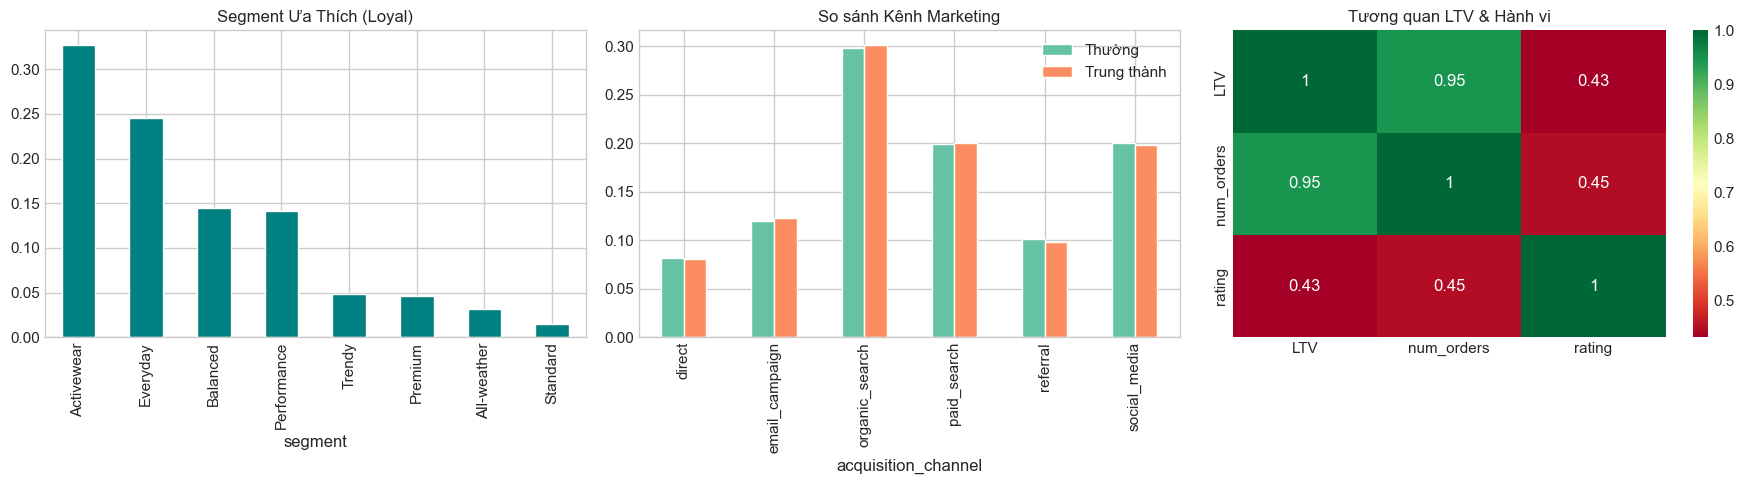

CHÂN DUNG KHÁCH HÀNG TRUNG THÀNH:
   - Quy mô: 16,371 khách (18.1%)
   - Hiệu quả: Mua gấp 5.6 lần, LTV cao gấp 5.9 lần nhóm thường.
   - Hành vi: Dùng khuyến mãi ít hơn (0.2%) nhưng rating cao hơn (0.00đ).
   - Marketing: Kênh ORGANIC_SEARCH mang lại tỷ lệ khách trung thành cao nhất.



In [ ]:
# ==============================================
# 1. CHUẨN HÓA KIỂU DỮ LIỆU & TÍNH LTV
# ==============================================

# Ép kiểu int64 cho tất cả ID để tránh lỗi Buffer dtype mismatch trên Windows
for df in [orders, order_items, customers, products, reviews]:
    if 'order_id' in df.columns: df['order_id'] = df['order_id'].astype('int64')
    if 'customer_id' in df.columns: df['customer_id'] = df['customer_id'].astype('int64')
    if 'product_id' in df.columns: df['product_id'] = df['product_id'].astype('int64')
if len(returns) > 0:
    returns['order_id'] = returns['order_id'].astype('int64')

# Tính doanh thu và refund theo đơn hàng
order_rev = order_items.assign(rev=order_items['quantity'] * order_items['unit_price']) \
                       .groupby('order_id')['rev'].sum().reset_index()

refund_order = returns.groupby('order_id')['refund_amount'].sum().reset_index() if len(returns) > 0 \
               else pd.DataFrame({'order_id': [], 'refund_amount': []})

# Tổng hợp hồ sơ khách hàng
cust_profile = orders.merge(order_rev, on='order_id', how='left') \
                     .merge(refund_order, on='order_id', how='left') \
                     .fillna(0)

df_cust = cust_profile.groupby('customer_id').agg(
    num_orders=('order_id', 'nunique'),
    total_rev=('rev', 'sum'),
    total_ref=('refund_amount', 'sum')
).reset_index()

df_cust['LTV'] = df_cust['total_rev'] - df_cust['total_ref']

# Gán nhãn Loyal (Top 15%)
q_ltv = df_cust['LTV'].quantile(0.85)
q_freq = df_cust['num_orders'].quantile(0.85)
df_cust['is_loyal'] = (df_cust['LTV'] >= q_ltv) | (df_cust['num_orders'] >= q_freq)

# Lấy danh sách ID (Lấy từ cột, không lấy từ index để an toàn)
loyal_ids = df_cust[df_cust['is_loyal']]['customer_id'].tolist()

# ==============================================
# 2. TÍNH TOÁN CHỈ SỐ SO SÁNH
# ==============================================

# Chuẩn bị bảng trung gian (Sử dụng merge an toàn với customer_id)
df_status = df_cust[['customer_id', 'is_loyal']]

orders_ly = orders.merge(df_status, on='customer_id')
items_ly = order_items.merge(orders_ly[['order_id', 'is_loyal']], on='order_id')
reviews_ly = reviews.merge(df_status, on='customer_id', how='left')

# Tính toán bảng metrics
metrics = df_cust.groupby('is_loyal').agg(
    avg_LTV=('LTV', 'mean'),
    avg_num_orders=('num_orders', 'mean')
)

# Thêm các chỉ số bổ trợ
metrics['avg_rating'] = reviews_ly.groupby('is_loyal')['rating'].mean()
metrics['promo_rate'] = items_ly.groupby('is_loyal')['promo_id'].apply(lambda x: x.notna().mean())
metrics['avg_order_val'] = cust_profile.merge(df_status, on='customer_id').groupby('is_loyal')['rev'].mean()

print("\n📊 SO SÁNH CHỈ SỐ TRUNG BÌNH (False: Thường, True: Trung thành):")
print(metrics.T.round(2))

# ==============================================
# 3. TRỰC QUAN HÓA
# ==============================================

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# A. Phân khúc sản phẩm (Nhóm Trung thành)
prod_loyal = items_ly[items_ly['is_loyal']].merge(products, on='product_id')
if not prod_loyal.empty:
    prod_loyal['segment'].value_counts(normalize=True).plot(kind='bar', ax=ax[0], color='teal', title='Segment Ưa Thích (Loyal)')

# B. Nguồn Traffic
traffic_data = customers.merge(df_status, on='customer_id')
traffic = traffic_data.groupby(['is_loyal', 'acquisition_channel']).size().unstack(0, fill_value=0)
if not traffic.empty:
    (traffic / traffic.sum()).plot(kind='bar', ax=ax[1], title='So sánh Kênh Marketing')
    ax[1].legend(["Thường", "Trung thành"])

# C. Ma trận tương quan (LTV & Hành vi)
corr_data = df_cust[['customer_id', 'LTV', 'num_orders']].copy()
avg_rating_map = reviews_ly.groupby('customer_id')['rating'].mean()
corr_data['rating'] = corr_data['customer_id'].map(avg_rating_map).fillna(0)
sns.heatmap(corr_data[['LTV', 'num_orders', 'rating']].corr(), annot=True, cmap='RdYlGn', ax=ax[2])
ax[2].set_title('Tương quan LTV & Hành vi')

plt.tight_layout()
plt.show()

# ==============================================
# 4. TỔNG KẾT INSIGHTS
# ==============================================

# Xác định kênh hiệu quả nhất
if not traffic.empty:
    # Tính chênh lệch tỷ lệ giữa Loyal và Regular
    diff = (traffic[True]/traffic[True].sum()) - (traffic[False]/traffic[False].sum())
    best_channel = diff.idxmax()
else:
    best_channel = "N/A"

l_m = metrics.loc[True] if True in metrics.index else pd.Series(dtype=float)
r_m = metrics.loc[False] if False in metrics.index else pd.Series(dtype=float)

print(f"""CHÂN DUNG KHÁCH HÀNG TRUNG THÀNH:
   - Quy mô: {len(loyal_ids):,} khách ({len(loyal_ids)/len(df_cust)*100:.1f}%)
   - Hiệu quả: Mua gấp {l_m['avg_num_orders']/r_m['avg_num_orders']:.1f} lần, LTV cao gấp {l_m['avg_LTV']/r_m['avg_LTV']:.1f} lần nhóm thường.
   - Hành vi: Dùng khuyến mãi ít hơn ({(r_m['promo_rate'] - l_m['promo_rate'])*100:.1f}%) nhưng rating cao hơn ({l_m['avg_rating']-r_m['avg_rating']:.2f}đ).
   - Marketing: Kênh {best_channel.upper()} mang lại tỷ lệ khách trung thành cao nhất.
""")

### 1. Biểu đồ:
- Biểu đồ cột này thể hiện tỷ lệ các phân khúc sản phẩm mà nhóm khách hàng trung thành quan tâm nhất.
- Nhóm dẫn đầu: Activewear (Đồ thể thao) chiếm tỷ lệ cao nhất (trên 30%), theo sau là Everyday (Đồ mặc hàng ngày) khoảng 25%.
- Nhóm tầm trung: Các phân khúc Balanced và Performance có tỷ lệ xấp xỉ nhau (khoảng 14-15%).
- Nhóm thấp: Các dòng sản phẩm như Trendy, Premium, All-weather và Standard đóng góp rất ít vào sở thích của khách hàng trung thành (đều dưới 5%).

#### Insight: Để giữ chân khách hàng trung thành, doanh nghiệp nên tập trung vào chất lượng và mẫu mã của dòng Activewear và Everyday vì đây là "long mạch" của nhóm này.

### 2. Biểu đồ: So sánh Kênh Marketing (Thường vs Trung thành)
- Biểu đồ cột đôi so sánh hiệu quả của các kênh thu hút khách hàng (Acquisition Channel) giữa khách hàng Thường (Regular) và khách hàng Trung thành (Loyal).
- Kênh hiệu quả nhất: Organic Search (Tìm kiếm tự nhiên) là kênh quan trọng nhất cho cả hai nhóm, chiếm tỷ trọng cao nhất (khoảng 30%).
- Sự tương đồng: Đáng chú ý là cấu trúc kênh của khách hàng Thường và Trung thành gần như tương đồng tuyệt đối. Không có kênh nào đặc biệt vượt trội trong việc tạo ra khách hàng trung thành so với khách hàng thường.

Thứ tự hiệu quả: 1.  Organic Search (~30%)
2.  Paid Search và Social Media (~20%)
3.  Email Campaign (~12%)
4.  Referral và Direct (dưới 10%)

#### Insight: Các nỗ lực SEO (Organic) và Quảng cáo trả phí/Mạng xã hội đang mang lại luồng khách hàng ổn định. Tuy nhiên, vì không có sự khác biệt giữa hai nhóm, doanh nghiệp có thể cần xem lại chiến dịch Email hoặc Referral để thiết kế riêng cho việc chuyển đổi khách hàng thường thành trung thành.

### 3. Biểu đồ: Tương quan LTV & Hành vi (Heatmap)
- Đây là ma trận tương quan (Correlation Matrix) đo lường mối quan hệ giữa: LTV (Giá trị vòng đời khách hàng), num_orders (Số lượng đơn hàng) và rating (Điểm đánh giá).

- Tương quan cực kỳ mạnh (0.95): Giữa LTV và num_orders. Điều này rất logic: khách hàng càng đặt nhiều đơn hàng thì giá trị vòng đời của họ càng cao. Đây là yếu tố then chốt để tăng trưởng doanh thu.

- Tương quan trung bình thấp (0.43 - 0.45): Giữa Rating với LTV và num_orders.

- Chỉ số này cho thấy việc khách hàng đánh giá cao (5 sao) không nhất thiết đồng nghĩa với việc họ sẽ mua hàng nhiều hơn hoặc có LTV cao hơn một cách tương ứng.

- Ngược lại, những người mua nhiều cũng chưa chắc là những người chăm chỉ đánh giá cao nhất.

#### Insight: Để tăng LTV, chiến lược hiệu quả nhất là tập trung vào việc tăng số lượng đơn hàng lặp lại (Retention) thay vì chỉ tập trung vào việc xin đánh giá/rating từ khách hàng